In [1]:
import os
import pickle

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
MODELS_DIR = "../models/do-demand/"

results = []

for model_name in os.listdir(MODELS_DIR):

    result_path = os.path.join(
        MODELS_DIR,
        model_name,
        "results.pkl"
    )

    if os.path.exists(result_path):

        with open(result_path, "rb") as f:
            metrics = pickle.load(f)

        metrics["Model"] = model_name

        results.append(metrics)

df = pd.DataFrame(results)

df.head()

,best_r2,best_params,rmse_mean,rmse_std,r2_mean,r2_std,rae_mean,rae_std,test_metrics,Model
0,0.909782,"{'n_estimators': 100, 'learning_rate': 0.1, 'm...",16.036545,0.161761,0.909782,0.001694,0.267230,0.002143,"{'RMSE': 15.52853707703677, 'R2': 0.9149227190...",lightgbm
1,NaN,NaN,32.699483,0.100873,0.625285,0.001368,0.535180,0.001199,"{'RMSE': 32.466381853102966, 'R2': 0.628105034...",linear_regression
2,0.822131,"{'n_estimators': 100, 'max_depth': 20, 'min_sa...",22.517103,0.145810,0.822131,0.002793,0.381593,0.003096,"{'RMSE': 22.270389797026585, 'R2': 0.825012046...",random_forest
3,0.891132,"{'n_estimators': 100, 'max_depth': 8, 'learnin...",17.616604,0.100393,0.891132,0.001269,0.267963,0.002000,"{'RMSE': 17.263745167549704, 'R2': 0.894846796...",xgboost


In [3]:
columns = [
    "Model",
    "rmse_mean",
    "rmse_std",
    "r2_mean",
    "r2_std",
    "rae_mean",
    "rae_std"
]

df = df[columns]

df.sort_values(
    by="r2_mean",
    ascending=False,
    inplace=True
)

df.reset_index(drop=True, inplace=True)

df.to_csv(
    "../results/results_do_summary.csv",
    index=False
)

df

,Model,rmse_mean,rmse_std,r2_mean,r2_std,rae_mean,rae_std
0,lightgbm,16.036545,0.161761,0.909782,0.001694,0.267230,0.002143
1,xgboost,17.616604,0.100393,0.891132,0.001269,0.267963,0.002000
2,random_forest,22.517103,0.145810,0.822131,0.002793,0.381593,0.003096
3,linear_regression,32.699483,0.100873,0.625285,0.001368,0.535180,0.001199


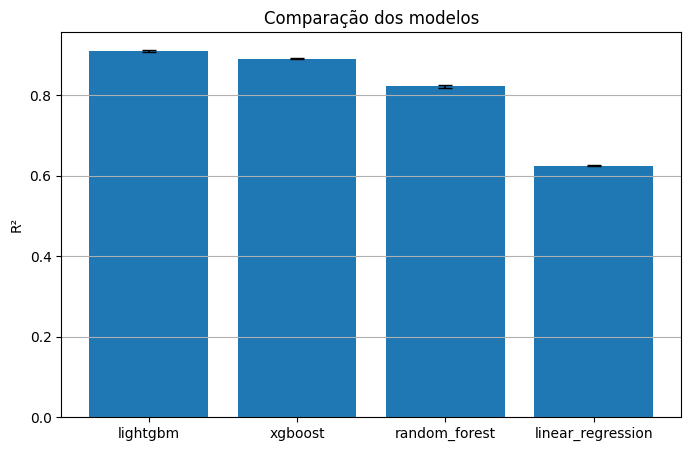

In [4]:
plt.figure(figsize=(8,5))

plt.bar(
    df["Model"],
    df["r2_mean"],
    yerr=df["r2_std"],
    capsize=5
)

plt.ylabel("R²")
plt.title("Comparação dos modelos")
plt.grid(axis="y")

plt.show()

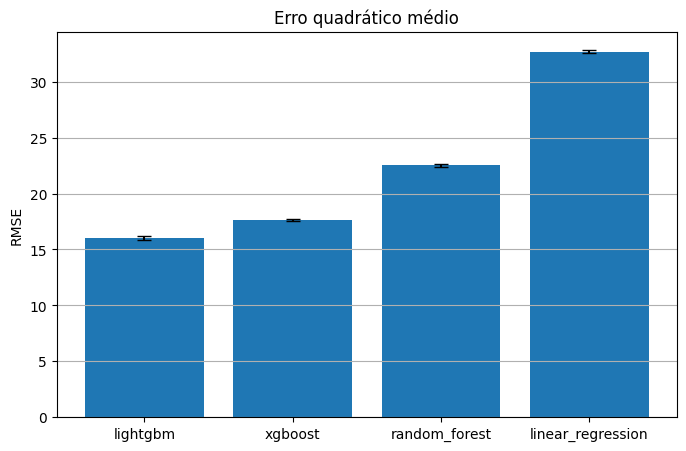

In [5]:
plt.figure(figsize=(8,5))

plt.bar(
    df["Model"],
    df["rmse_mean"],
    yerr=df["rmse_std"],
    capsize=5
)

plt.ylabel("RMSE")
plt.title("Erro quadrático médio")
plt.grid(axis="y")

plt.show()

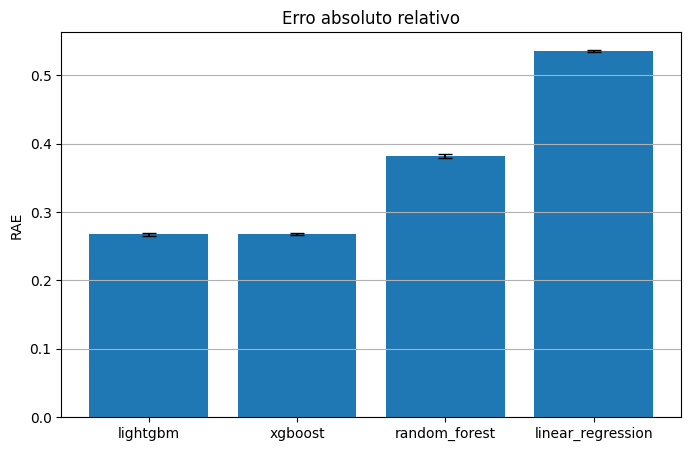

In [6]:
plt.figure(figsize=(8,5))

plt.bar(
    df["Model"],
    df["rae_mean"],
    yerr=df["rae_std"],
    capsize=5
)

plt.ylabel("RAE")
plt.title("Erro absoluto relativo")
plt.grid(axis="y")

plt.show()

In [7]:
ranking = df.sort_values(
    by="r2_mean",
    ascending=False
)

ranking[[
    "Model",
    "r2_mean",
    "rmse_mean",
    "rae_mean"
]]

,Model,r2_mean,rmse_mean,rae_mean
0,lightgbm,0.909782,16.036545,0.267230
1,xgboost,0.891132,17.616604,0.267963
2,random_forest,0.822131,22.517103,0.381593
3,linear_regression,0.625285,32.699483,0.535180


In [8]:
ranking = df.copy()

ranking["Score"] = (
      ranking["r2_mean"]
    - ranking["rmse_mean"] / ranking["rmse_mean"].max()
    - ranking["rae_mean"]
)

ranking = ranking.sort_values(
    by="Score",
    ascending=False
)

ranking[[
    "Model",
    "Score"
]]

,Model,Score
0,lightgbm,0.152130
1,xgboost,0.084427
2,random_forest,-0.248069
3,linear_regression,-0.909894


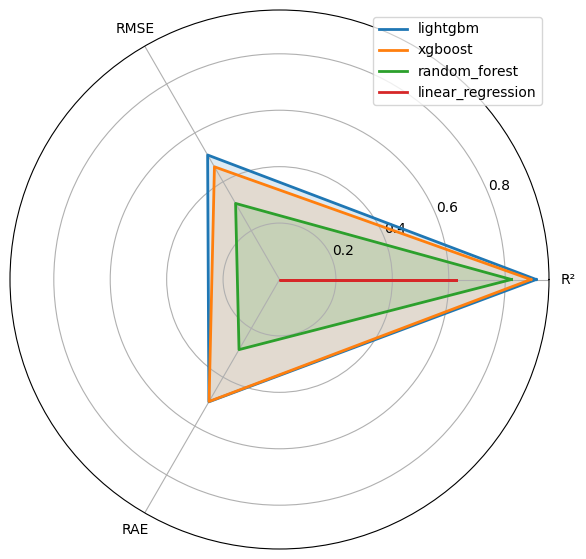

In [9]:
from math import pi

metrics = ["r2_mean", "rmse_mean", "rae_mean"]

plot = df.copy()

plot["rmse_mean"] = 1 - plot["rmse_mean"]/plot["rmse_mean"].max()
plot["rae_mean"] = 1 - plot["rae_mean"]/plot["rae_mean"].max()

angles = np.linspace(
    0,
    2*np.pi,
    len(metrics),
    endpoint=False
)

angles = np.concatenate([angles, [angles[0]]])
fig = plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

for _, row in plot.iterrows():

    values = [
        row["r2_mean"],
        row["rmse_mean"],
        row["rae_mean"]
    ]

    values.append(values[0])

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["Model"]
    )

    ax.fill(
        angles,
        values,
        alpha=0.15
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(["R²", "RMSE", "RAE"])

plt.legend()
plt.show()